In [ ]:
import marimo as mo

In [ ]:
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

from project_name.clients.http import HttpClient
from project_name.config import (
    load_dataset_config,
    load_logging,
    load_params,
)
from project_name.logging import log_execution
from project_name.policies.file import FilePolicy, OnExists

In [ ]:
params = load_params()
print(params)

{'logging': {'level': 'INFO', 'file': 'logs/project_name.log', 'console': False}, 'sources': {'inegi': {'name': 'Instituto Nacional de Estadística y Geografía', 'datasets': {'denue_sonora_2024_05': {'name': 'DENUE Sonora — mayo 2024', 'url': 'https://www.inegi.org.mx/contenidos/masiva/denue/2024_05/denue_26_0524_csv.zip', 'raw': {'directory': 'data/raw/inegi/denue', 'filename': 'denue_sonora_2024_05.zip'}, 'interim': {'directory': 'data/interim/inegi/denue'}, 'processed': {'directory': 'data/processed/inegi/denue', 'filename': 'denue_sonora_2024_05.parquet'}}}}}, 'defaults': {'download': {'on_exists': 'skip'}}}


In [ ]:
dataset = load_dataset_config(
    params,
    source="inegi",
    dataset="denue_sonora_2024_05",
)

raw_file = Path(dataset["raw"]["directory"]) / dataset["raw"]["filename"]

interim_dir = Path(dataset["interim"]["directory"])

In [ ]:
assert raw_file.exists()

In [ ]:
interim_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(raw_file, "r") as archive:
    archive.extractall(interim_dir)

for file in interim_dir.iterdir():
    print(file)

data/interim/inegi/denue/metadatos
data/interim/inegi/denue/diccionario_de_datos
data/interim/inegi/denue/conjunto_de_datos


In [ ]:
csv_file = next((interim_dir / "conjunto_de_datos").glob("*.csv"))

# El INEGI publica estos archivos en ISO-8859-1, no UTF-8; utf-8 lanza UnicodeDecodeError.
# low_memory=False evita un DtypeWarning al inferir el tipo de columnas mixtas (ej. telefono).
df = pd.read_csv(csv_file, encoding="latin-1", low_memory=False)

print(df.shape)
print(df.columns.tolist())
df.head()

(119501, 42)
['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta']


,id,clee,nom_estab,raz_social,codigo_act,nombre_act,per_ocu,tipo_vial,nom_vial,tipo_v_e_1,...,localidad,ageb,manzana,telefono,correoelec,www,tipoUniEco,latitud,longitud,fecha_alta
0,6179123,26018112511000101001000000U9,11 DE DICIEMBRE DE 1996,11 DE DICIEMBRE DE 1996,112511,Camaronicultura,31 a 50 personas,CALLE,FRANCISCO URBALEJO,CALLE,...,Los Médanos (Los Mélagos),0184,800,NaN,NaN,NaN,Fijo,27.155000,-110.302000,2010-07
1,6865042,26072112511000112001000000S3,3 SOCIOS SONORENSES,NaN,112511,Camaronicultura,51 a 100 personas,CALLEJON,JALISCO,CALLE,...,Los Médanos (Los Mélagos),0184,800,NaN,ALONSOGRAROG@HOTMAIL.COM,NaN,Fijo,27.154512,-110.300392,2019-04
2,7759547,26033114111001784000000000O7,A GARRA BANDIDO,A GARRA BANDIDO SC DE RL DE CV,114111,Pesca de camarón,11 a 30 personas,CALLE,NINGUNO,CALLE,...,Santa Bárbara,0398,800,NaN,NaN,NaN,Fijo,26.693991,-109.655856,2019-11
3,9278595,26018114119000262000000000U9,ACCION ACUACULTURA,SERVICIOS TECNICOS ACUICOLAS ACUICOLAS S DE RL DE CV,114119,"Pesca y captura de peces, crustáceos, moluscos y otras especies",6 a 10 personas,CALLE,GOLFO DE CALIFORNIA,CALLE,...,Ciudad Obregón,1879,37,NaN,NaN,NaN,Fijo,27.481988,-109.963184,2020-11
4,6743802,26018112511000771000000000U9,ACCION ACUACULTURA,ACCION ACUACULTURA SA DE CV,112511,Camaronicultura,0 a 5 personas,NaN,LICENCIADO MIGUEL ALEMÁN VELASCO,NaN,...,Ciudad Obregón,0762,8,NaN,NaN,NaN,Fijo,27.489144,-109.929915,2016-10


## De interim a processed
Seleccionamos las columnas relevantes del directorio DENUE, aplicamos algunas
transformaciones de ejemplo (feature engineering) y guardamos el resultado como
CSV en `data/processed/`.

In [ ]:
processed_dir = Path(dataset["processed"]["directory"])

# params.yml declara un archivo .parquet; por ahora exploramos guardando CSV.
processed_file = processed_dir / Path(
    dataset["processed"]["filename"]
).with_suffix(".csv")

In [ ]:
# Nos quedamos solo con las columnas relevantes para esta exploración.
columns = {
    "id": "id",
    "nom_estab": "business_name",
    "codigo_act": "activity_code",
    "nombre_act": "activity_name",
    "per_ocu": "employee_range",
    "municipio": "municipality",
    "localidad": "locality",
    "latitud": "latitude",
    "longitud": "longitude",
    "telefono": "phone",
    "correoelec": "email",
    "fecha_alta": "registration_date",
}

denue = df[list(columns)].rename(columns=columns)
denue.head()

,id,business_name,activity_code,activity_name,employee_range,municipality,locality,latitude,longitude,phone,email,registration_date
0,6179123,11 DE DICIEMBRE DE 1996,112511,Camaronicultura,31 a 50 personas,San Ignacio Río Muerto,Los Médanos (Los Mélagos),27.155000,-110.302000,NaN,NaN,2010-07
1,6865042,3 SOCIOS SONORENSES,112511,Camaronicultura,51 a 100 personas,San Ignacio Río Muerto,Los Médanos (Los Mélagos),27.154512,-110.300392,NaN,ALONSOGRAROG@HOTMAIL.COM,2019-04
2,7759547,A GARRA BANDIDO,114111,Pesca de camarón,11 a 30 personas,Huatabampo,Santa Bárbara,26.693991,-109.655856,NaN,NaN,2019-11
3,9278595,ACCION ACUACULTURA,114119,"Pesca y captura de peces, crustáceos, moluscos y otras especies",6 a 10 personas,Cajeme,Ciudad Obregón,27.481988,-109.963184,NaN,NaN,2020-11
4,6743802,ACCION ACUACULTURA,112511,Camaronicultura,0 a 5 personas,Cajeme,Ciudad Obregón,27.489144,-109.929915,NaN,NaN,2016-10


### Transformaciones de ejemplo
- `employee_range` → `employee_range_rank`: codificamos el rango de personal
  ocupado como un valor ordinal, ya que pandas no puede inferir su orden natural.
- `registration_date`: se convierte a un `datetime` real a partir del string `YYYY-MM`.
- `phone` / `email`: como la mayoría de los registros no los tienen, los
  reemplazamos por banderas booleanas (`has_phone`, `has_email`) que indican
  presencia en vez de guardar el valor crudo.

In [ ]:
# Los rangos tienen un orden natural que pandas no puede inferir solo.
employee_range_order = {
    "0 a 5 personas": 1,
    "6 a 10 personas": 2,
    "11 a 30 personas": 3,
    "31 a 50 personas": 4,
    "51 a 100 personas": 5,
    "101 a 250 personas": 6,
    "251 y más personas": 7,
}

# Un par de valores usan espacio en vez de guion (ej. "2013 07"); los normalizamos.
registration_date = denue["registration_date"].str.replace(
    " ", "-", regex=False
)

denue_clean = denue.assign(
    employee_range_rank=denue["employee_range"].map(employee_range_order),
    registration_date=pd.to_datetime(registration_date, format="%Y-%m"),
    # La mayoría de los registros no tienen teléfono/correo; la presencia
    # es una señal más útil que el valor crudo.
    has_phone=denue["phone"].notna(),
    has_email=denue["email"].notna(),
).drop(columns=["phone", "email"])

denue_clean.dtypes

,0
id,int64
business_name,str
activity_code,int64
activity_name,str
employee_range,str
...,...
longitude,float64
registration_date,datetime64[us]
employee_range_rank,int64
has_phone,bool


In [ ]:
denue_clean.head()

,id,business_name,activity_code,activity_name,employee_range,municipality,locality,latitude,longitude,registration_date,employee_range_rank,has_phone,has_email
0,6179123,11 DE DICIEMBRE DE 1996,112511,Camaronicultura,31 a 50 personas,San Ignacio Río Muerto,Los Médanos (Los Mélagos),27.155000,-110.302000,2010-07-01,4,False,False
1,6865042,3 SOCIOS SONORENSES,112511,Camaronicultura,51 a 100 personas,San Ignacio Río Muerto,Los Médanos (Los Mélagos),27.154512,-110.300392,2019-04-01,5,False,True
2,7759547,A GARRA BANDIDO,114111,Pesca de camarón,11 a 30 personas,Huatabampo,Santa Bárbara,26.693991,-109.655856,2019-11-01,3,False,False
3,9278595,ACCION ACUACULTURA,114119,"Pesca y captura de peces, crustáceos, moluscos y otras especies",6 a 10 personas,Cajeme,Ciudad Obregón,27.481988,-109.963184,2020-11-01,2,False,False
4,6743802,ACCION ACUACULTURA,112511,Camaronicultura,0 a 5 personas,Cajeme,Ciudad Obregón,27.489144,-109.929915,2016-10-01,1,False,False


In [ ]:
processed_dir.mkdir(parents=True, exist_ok=True)
denue_clean.to_csv(processed_file, index=False)

print(f"Guardadas {len(denue_clean)} filas -> {processed_file}")

Guardadas 119501 filas -> data/processed/inegi/denue/denue_sonora_2024_05.csv


## Visualizaciones
Leemos el CSV recién guardado en `data/processed/` (no el dataframe en memoria)
para confirmar que lo que quedó en disco es justo lo que queremos graficar.

In [ ]:
processed_df = pd.read_csv(processed_file, parse_dates=["registration_date"])
processed_df.head()

,id,business_name,activity_code,activity_name,employee_range,municipality,locality,latitude,longitude,registration_date,employee_range_rank,has_phone,has_email
0,6179123,11 DE DICIEMBRE DE 1996,112511,Camaronicultura,31 a 50 personas,San Ignacio Río Muerto,Los Médanos (Los Mélagos),27.155000,-110.302000,2010-07-01,4,False,False
1,6865042,3 SOCIOS SONORENSES,112511,Camaronicultura,51 a 100 personas,San Ignacio Río Muerto,Los Médanos (Los Mélagos),27.154512,-110.300392,2019-04-01,5,False,True
2,7759547,A GARRA BANDIDO,114111,Pesca de camarón,11 a 30 personas,Huatabampo,Santa Bárbara,26.693991,-109.655856,2019-11-01,3,False,False
3,9278595,ACCION ACUACULTURA,114119,"Pesca y captura de peces, crustáceos, moluscos y otras especies",6 a 10 personas,Cajeme,Ciudad Obregón,27.481988,-109.963184,2020-11-01,2,False,False
4,6743802,ACCION ACUACULTURA,112511,Camaronicultura,0 a 5 personas,Cajeme,Ciudad Obregón,27.489144,-109.929915,2016-10-01,1,False,False


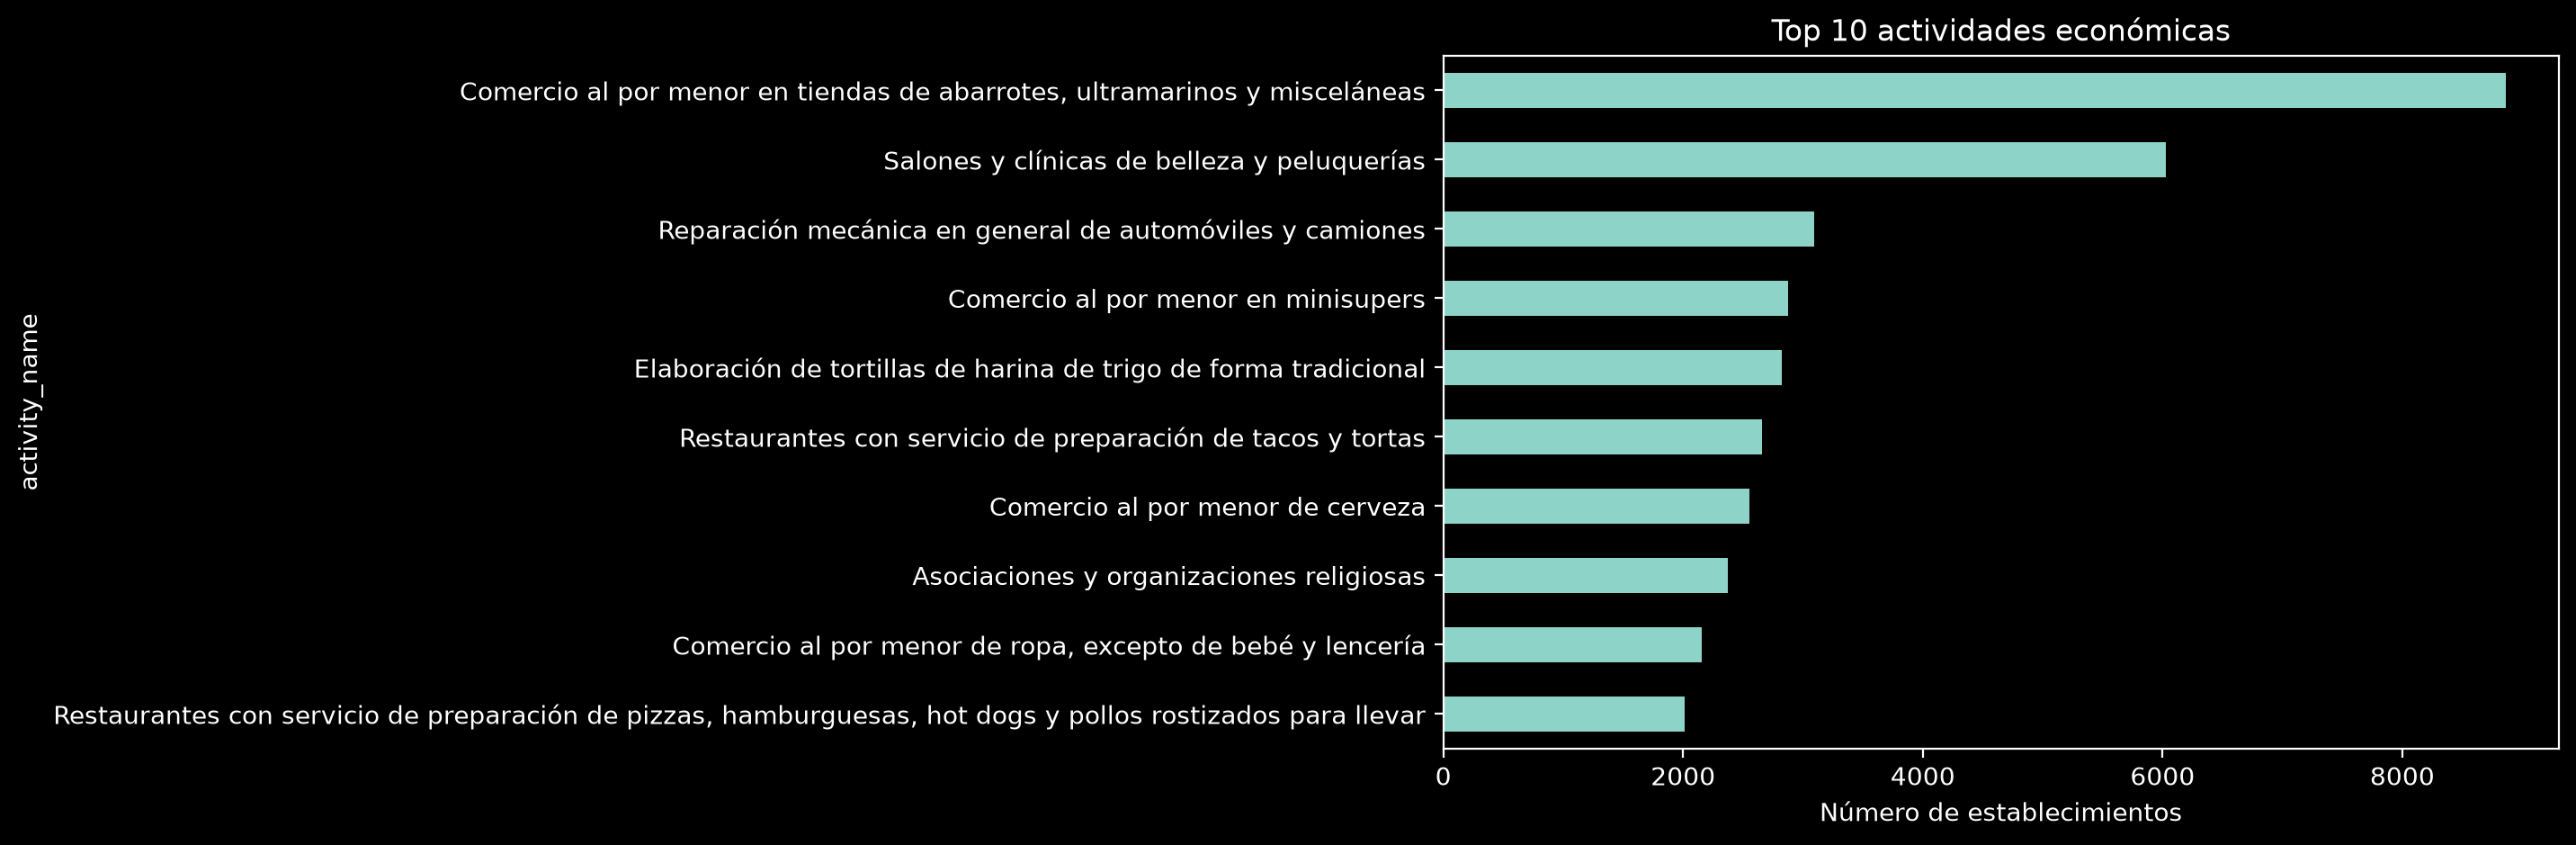

In [ ]:
# Top 10 actividades económicas por número de establecimientos.
top_activities = processed_df["activity_name"].value_counts().head(10).sort_values()

fig_activities, ax_activities = plt.subplots(figsize=(8, 5))
top_activities.plot.barh(ax=ax_activities)
ax_activities.set_xlabel("Número de establecimientos")
ax_activities.set_title("Top 10 actividades económicas")
fig_activities

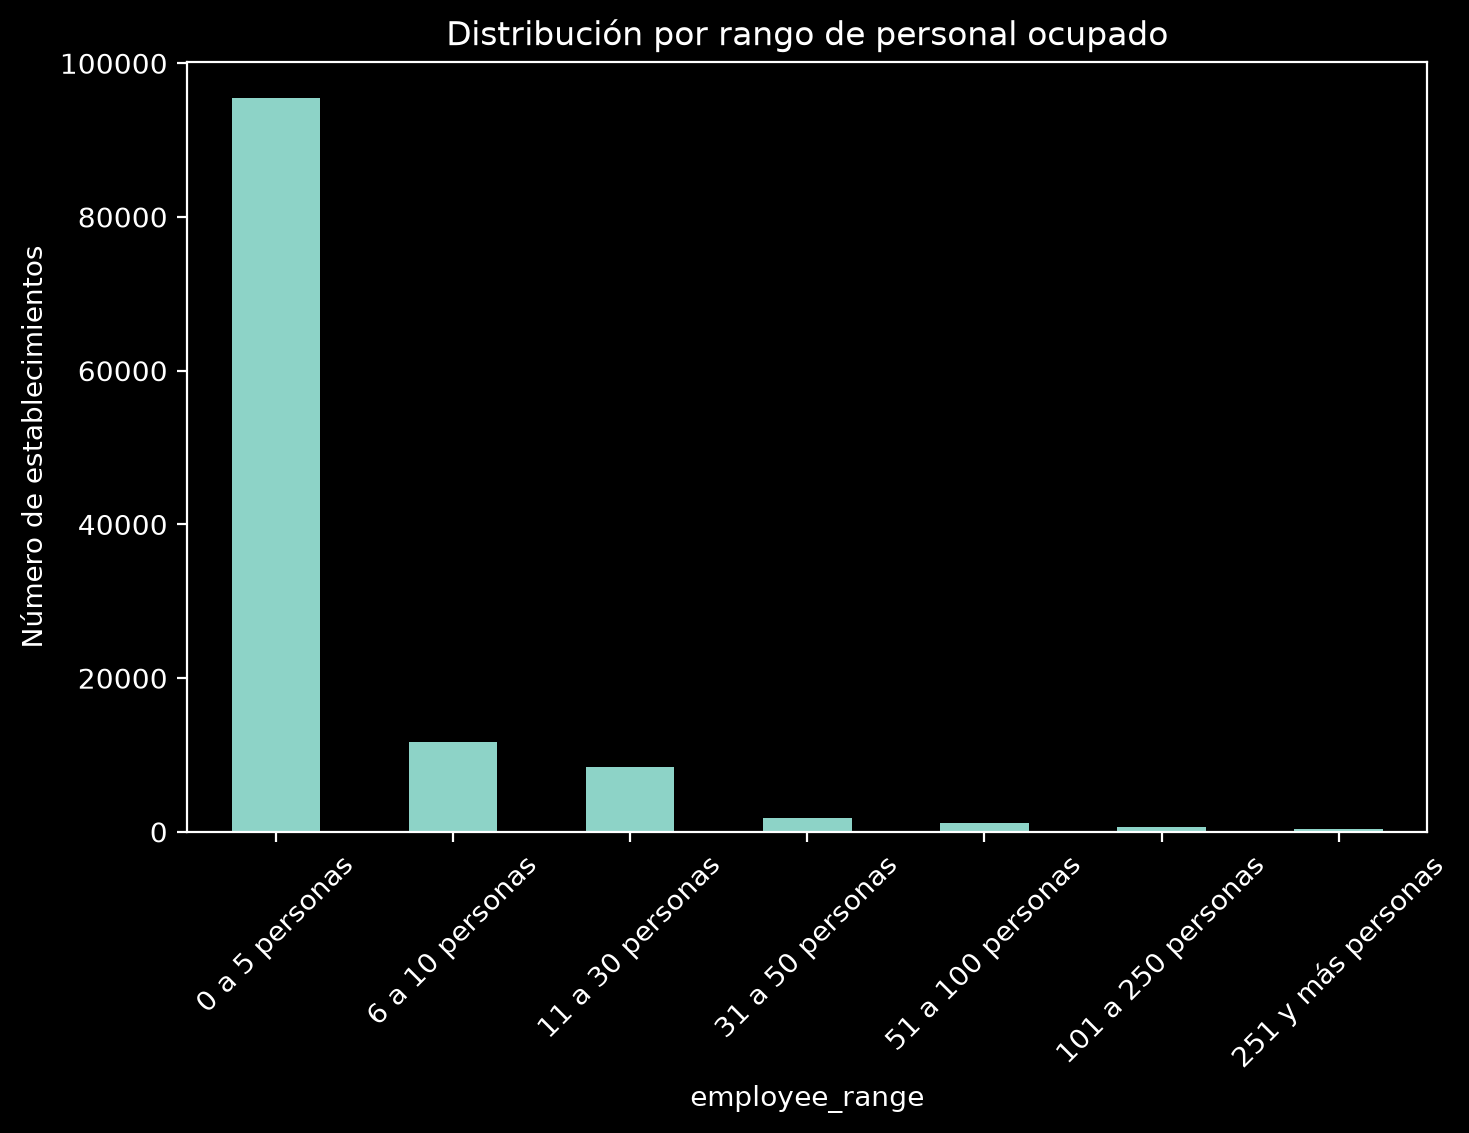

In [ ]:
# Distribución de establecimientos por rango de personal ocupado,
# ordenada por employee_range_rank en vez del orden alfabético.
employee_range_counts = processed_df.groupby(
    ["employee_range_rank", "employee_range"]
).size()

fig_employee_range, ax_employee_range = plt.subplots(figsize=(8, 5))
employee_range_counts.reset_index(level=0, drop=True).plot.bar(ax=ax_employee_range)
ax_employee_range.set_ylabel("Número de establecimientos")
ax_employee_range.set_title("Distribución por rango de personal ocupado")
ax_employee_range.tick_params(axis="x", rotation=45)
fig_employee_range

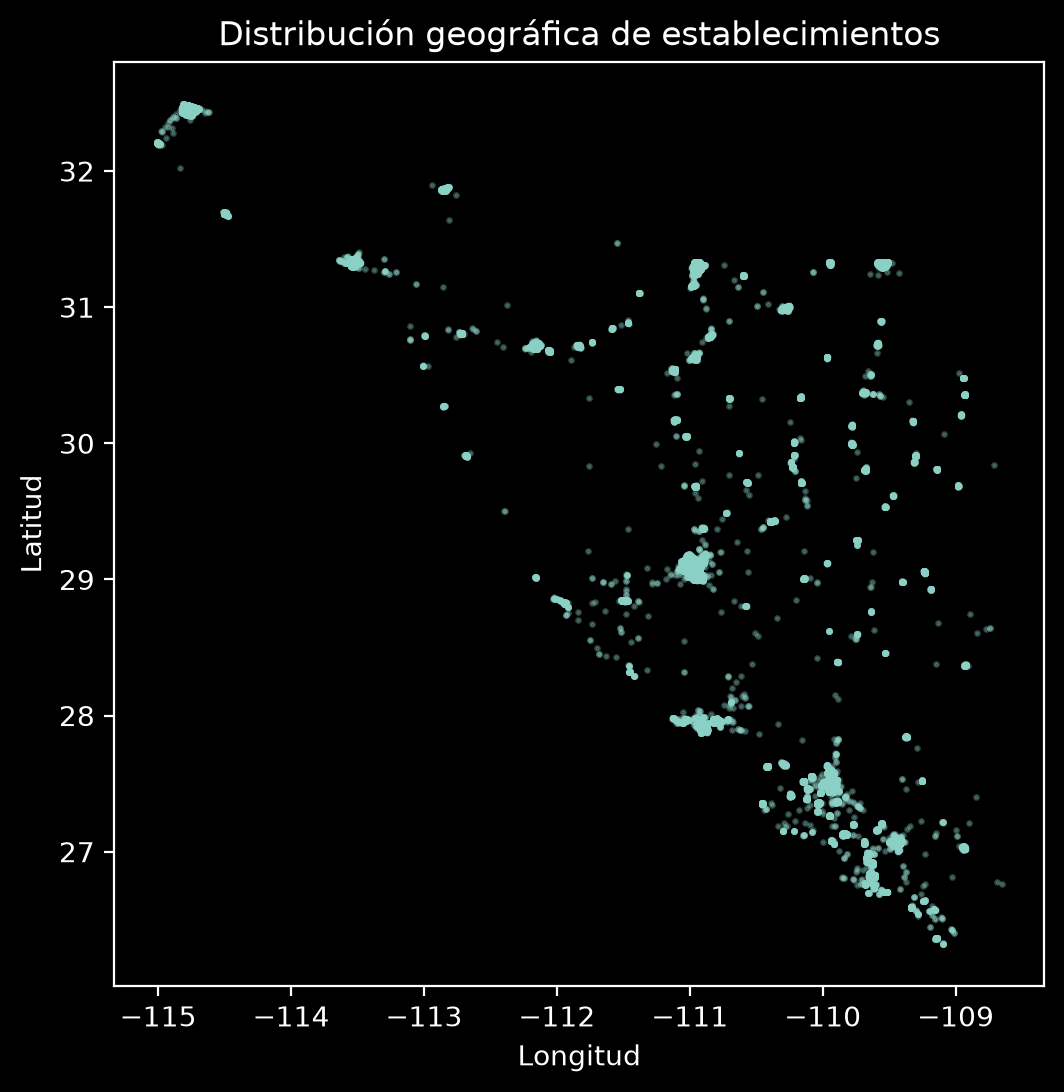

In [ ]:
# Distribución geográfica: cada establecimiento como un punto lat/long.
fig_map, ax_map = plt.subplots(figsize=(6, 6))
ax_map.scatter(processed_df["longitude"], processed_df["latitude"], s=2, alpha=0.3)
ax_map.set_xlabel("Longitud")
ax_map.set_ylabel("Latitud")
ax_map.set_title("Distribución geográfica de establecimientos")
fig_map